<a href="https://colab.research.google.com/github/lk123niwuebdsvbdVFOY/Pandas/blob/AI/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("/content/kyphosis.csv")
data

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15
...,...,...,...,...
76,present,157,3,13
77,absent,26,7,13
78,absent,120,2,13
79,present,42,7,6


In [3]:
data.head()

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Kyphosis  81 non-null     object
 1   Age       81 non-null     int64 
 2   Number    81 non-null     int64 
 3   Start     81 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 2.7+ KB


In [5]:
data.describe()

,Age,Number,Start
count,81.000000,81.000000,81.000000
mean,83.654321,4.049383,11.493827
std,58.104251,1.619423,4.883962
min,1.000000,2.000000,1.000000
25%,26.000000,3.000000,9.000000
50%,87.000000,4.000000,13.000000
75%,130.000000,5.000000,16.000000
max,206.000000,10.000000,18.000000


In [6]:
data.isnull().sum()

,0
Kyphosis,0
Age,0
Number,0
Start,0


In [7]:
data.head(2)

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14


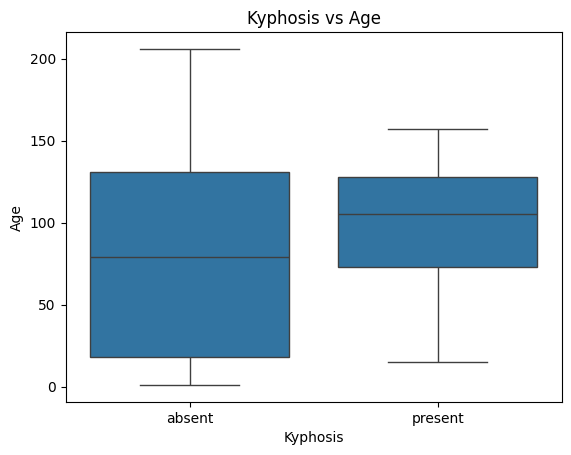

In [8]:
sns.boxplot(x='Kyphosis',y='Age',data=data)
plt.xlabel('Kyphosis')
plt.ylabel('Age')
plt.title('Kyphosis vs Age')
plt.show()

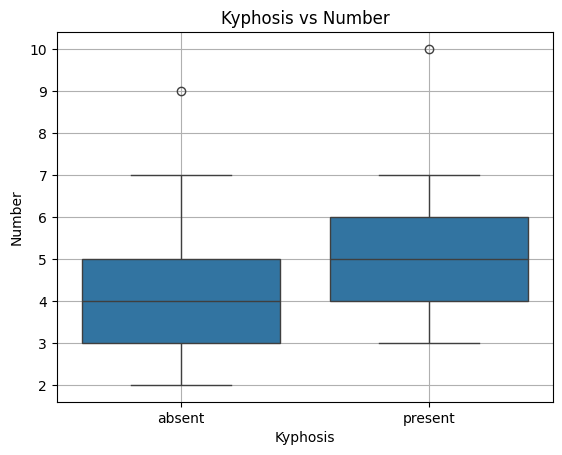

In [11]:
sns.boxplot(x='Kyphosis',y='Number',data=data)
plt.xlabel('Kyphosis')
plt.ylabel('Number')
plt.title('Kyphosis vs Number')
plt.grid()
plt.show()


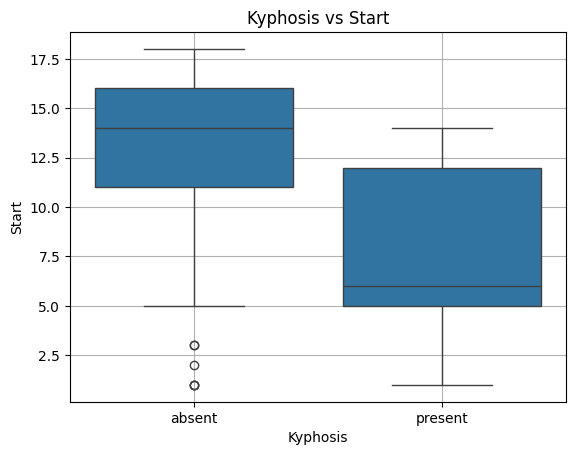

In [12]:
sns.boxplot(x='Kyphosis',y='Start',data=data)
plt.xlabel('Kyphosis')
plt.ylabel('Start')
plt.title('Kyphosis vs Start')
plt.grid()
plt.show()

In [13]:
data.head(2)

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14


In [24]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['Kyphosis'] = le.fit_transform(data['Kyphosis'])

In [25]:
x = data[['Age','Number','Start']]
y = data['Kyphosis']

In [26]:
data

,Kyphosis,Age,Number,Start
0,0,71,3,5
1,0,158,3,14
2,1,128,4,5
3,0,2,5,1
4,0,1,4,15
...,...,...,...,...
76,1,157,3,13
77,0,26,7,13
78,0,120,2,13
79,1,42,7,6


In [51]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=9876)

In [52]:
from sklearn.svm import SVR
svr = SVR(kernel='linear')
svr.fit(x_train,y_train)

SVR(kernel='linear')

In [58]:
svr_y = svr.predict(x_test)

In [60]:
from sklearn.metrics import accuracy_score

svr_y_binary = (svr_y > 0.5).astype(int)

print(accuracy_score(y_test,svr_y_binary))

0.9047619047619048
